# Geopack SDK: Data Analysis with GeoPandas

This notebook demonstrates how to load vector datasets from Geopack directly into **GeoPandas GeoDataFrames** for spatial analysis and visualization.

---

### 🚀 Setup Note
This notebook is configured to work both with an installed `geopack-sdk` package or directly from the repository source code (`src/` folder).

---

In [6]:
import os
import sys
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- SMART SOURCE IMPORT ---
# Ensures we use the local 'src' directory with high priority
try:
    current_dir = os.getcwd()
    source_path = os.path.abspath(os.path.join(current_dir, "..", "src"))
    if os.path.exists(source_path):
        if source_path not in sys.path:
            sys.path.insert(0, source_path)
        print(f"ℹ️ Using SDK from local source: {source_path}")
    else:
        print("ℹ️ Using SDK from installed site-packages (pip)")
except Exception:
    print("⚠️ Could not determine local source path, falling back to pip.")

from geopack_sdk import GeopackClient

load_dotenv()
client = GeopackClient(base_url=os.getenv("GEOPACK_API_URL", "http://localhost:3000/api"))

# Login using credentials from .env or defaults
try:
    client.auth.login(
        os.getenv("GEOPACK_USERNAME", "admin"), 
        os.getenv("GEOPACK_PASSWORD", "password")
    )
    print("✅ Login successful!")
except Exception as e:
    print(f"❌ Login failed: {e}")


ℹ️ Using SDK from local source: d:\Works\geopack-geoportal\geopack-geoportal-v2\python-sdk\src
✅ Login successful!


## 1. Finding a Vector Dataset
We use the filtering system to find a suitable vector dataset.

In [22]:
# 1. List available vector datasets
vector_datasets = client.datasets.list(page_size=50, active_filters={"dataType": "vector"})

if not vector_datasets:
    print("❌ No vector datasets found. Please upload a shapefile or geojson first.")
else:
    print(f"Available Vector Datasets ({len(vector_datasets)}):")
    for ds in vector_datasets:
        print(f"- [{ds['id']}] {ds['name']} (Type: {ds['dataType']})")

    # --- SELECT YOUR DATASET HERE ---
    # We pick the first one by default, but you can change the ID below
    SELECTED_DATASET_ID = vector_datasets[0]['id']
    print(f"\n✅ Selected Dataset ID: {SELECTED_DATASET_ID}")


Available Vector Datasets (50):
- [2362] Rural_District.shp (Type: vector)
- [2361] Rural_District.shp (Type: vector)
- [2360] Rural_District.shp (Type: vector)
- [2359] Rural_District.shp (Type: vector)
- [2357] Rural_District.shp (Type: vector)
- [2342] Rural_District.shp (Type: vector)
- [2341] Rural_District.shp (Type: vector)
- [2340] Rural_District.shp (Type: vector)
- [2339] Rural_District.shp (Type: vector)
- [2338] Rural_District.shp (Type: vector)
- [2337] Rural_District.shp (Type: vector)
- [2293] مکانیابی احداث پارکینگ دوچرخه (Type: vector)
- [2258] suitability (Type: vector)
- [2257] suitability (Type: vector)
- [1843] محدوده ی مکانیابی (Type: vector)
- [1844] پارکینگ دوچرخه (Type: vector)
- [1845] مسیر دوچرخه سواری (Type: vector)
- [1842] دزدی دوچرخه (Type: vector)
- [2186] parcel (Type: vector)
- [2183] outputXYpoints (Type: vector)
- [2182] outputXYpoints (Type: vector)
- [1829] Rck_Typ (Type: vector)
- [2168] t1 (Type: vector)
- [2165] cycling_routes (Type: vector)
- [

## 2. Converting to GeoDataFrame
The `to_geodataframe()` method handles the GeoJSON fetching and conversion automatically, including CRS assignment.

In [24]:
#SELECTED_DATASET_ID=1829
# Fetch the data into a GeoDataFrame
# This handles GeoJSON streaming and CRS conversion automatically
gdf = client.datasets.to_geodataframe(SELECTED_DATASET_ID, limit=500)

print(f"Loaded {len(gdf)} features.")
print(f"CRS: {gdf.crs}")
gdf.head()


Loaded 118 features.
CRS: EPSG:4326


,geometry,b,att,distr_id,objectid,city_name,prec_code,shapearea,centr_name,distr_code,distr_name,locen_code,population,shape_area,shape_leng,تصاویر
0,"MULTIPOLYGON (((57.00182 30.48455, 57.00013 30...",None,None,40,40,�����- ����,12,0.032096,����,659,�����,9,7087,0,1,None
1,"MULTIPOLYGON (((57.54738 30.71374, 57.54599 30...",None,None,39,39,�����,12,0.200373,�����,658,�����,9,2819,0,2,None
2,"MULTIPOLYGON (((57.00182 30.48455, 57.00013 30...",None,None,79,79,����,12,0.032096,����,2285,����,9,666666,0,1,None
3,"MULTIPOLYGON (((57.65099 30.19651, 57.65183 30...",None,None,28,28,�����,12,0.128499,�����,612,�����,9,2007,0,2,None
4,"MULTIPOLYGON (((57.4796 30.09901, 57.49321 30....",None,None,27,27,����� -���,12,0.126809,���,611,�����,9,3560,0,1,None


## 3. Spatial Analysis & Visualization
Now we can use native GeoPandas and Matplotlib functions.

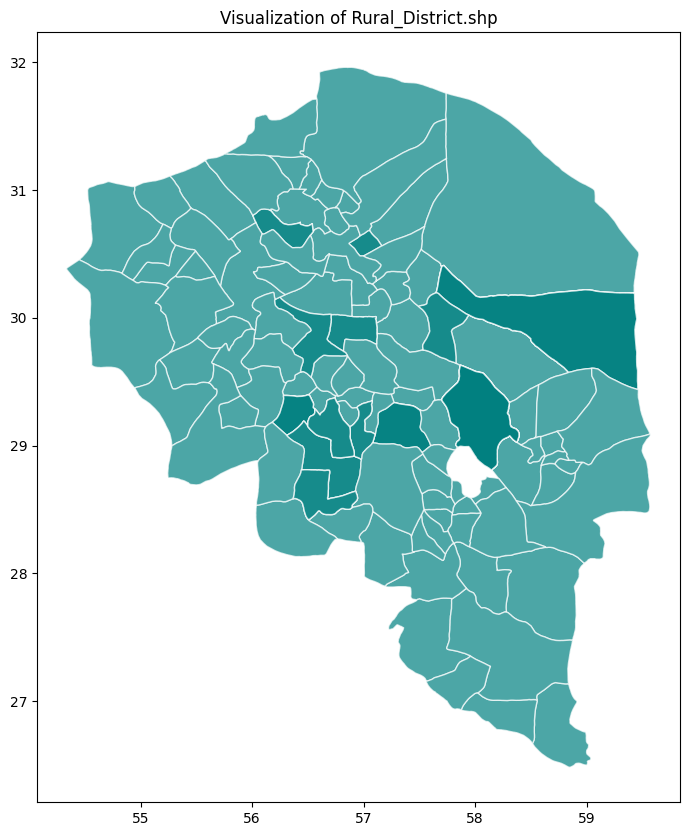

In [26]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='teal', edgecolor='white', alpha=0.7)
ax.set_title(f"Visualization of {target_ds['name']}")
plt.show()

## 4. Basic Statistics
Analyze the attributes of the spatial data.

In [19]:
# Display area statistics (if polygons)
if 'area' in gdf.columns or 'shape_area' in gdf.columns:
    area_col = 'area' if 'area' in gdf.columns else 'shape_area'
    print(f"Average Area: {gdf[area_col].mean():.2f}")
else:
    print("Attribute columns summary:")
    print(gdf.describe())

Average Area: 14274.53
